In [ ]:
!pip install ultralytics pyyaml -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 36.0 MB/s eta 0:00:00


In [ ]:
from google.colab import files
import os

# Upload your dataset ZIP from local machine (must contain images/ and labels/ + data.yaml)
uploaded = files.upload()
zip_files = [name for name in uploaded if name.lower().endswith('.zip')]
if not zip_files:
    raise ValueError('Please upload a .zip dataset file')

zip_name = zip_files[0]
os.makedirs('/content/dataset', exist_ok=True)

# Extract dataset to /content/dataset
!unzip -q "$zip_name" -d /content/dataset
print(f'Extracted: {zip_name}')

upload and label your dataset, and get an API KEY here: https://app.roboflow.com/?model=undefined&ref=undefined
loading Roboflow workspace...


RoboflowError: {"error":{"message":"This API key does not exist (or has been revoked).","status":401,"type":"OAuthException","hint":"You may retrieve your API key via the Roboflow Dashboard. Go to Account > Roboflow Keys to retrieve yours.","key":"YOUR_FULL_API_KEY"}}

In [ ]:
from pathlib import Path

# Find data.yaml automatically inside extracted dataset
dataset_root = Path('/content/dataset')
yaml_files = list(dataset_root.rglob('data.yaml'))
if not yaml_files:
    raise FileNotFoundError('No data.yaml found inside uploaded zip')

data_yaml = str(yaml_files[0])
print('Using data yaml:', data_yaml)

# Optional quick check of extracted folders
for p in dataset_root.iterdir():
    print('-', p)

loading Roboflow workspace...
loading Roboflow project...
Exporting format yolov8 in progress : 95.0%
Version export complete for yolov8 format



Extracting Dataset Version Zip to Obstacle-Detection-1 in yolov8:: 100%|██████████| 9989/9989 [00:04<00:00, 2321.54it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
import yaml

# Read and print class info from data.yaml
with open(data_yaml, 'r', encoding='utf-8') as f:
    data_cfg = yaml.safe_load(f)

names = data_cfg.get('names', {})
num_classes = len(names) if isinstance(names, (list, dict)) else 0
print('Detected classes:', num_classes)
print('Classes preview:', names if num_classes <= 20 else 'Too many classes, showing first 20 only')
if isinstance(names, dict) and num_classes > 20:
    print({k: names[k] for k in list(names.keys())[:20]})
elif isinstance(names, list) and num_classes > 20:
    print(names[:20])

loading Roboflow workspace...
loading Roboflow project...
[]


In [ ]:
from ultralytics import YOLO
from pathlib import Path

model = YOLO('yolov8n.pt')

results = model.train(
    data=data_yaml,
    epochs=100,
    imgsz=640,
    batch=16,
    name='custom_dataset_train',
    patience=20,
    device=0,
    workers=2,
    augment=True
)

best_path = Path(results.save_dir) / 'weights' / 'best.pt'
print('Training complete. best.pt path:', best_path)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Obstacle-Detection-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=hexapod_obstacle, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tr

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  6,  8, 10, 11, 12, 13, 14])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7946e03dc920>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.

In [ ]:
metrics = model.val()
print(f"mAP@0.5    : {metrics.box.map50:.3f}")
print(f"Precision  : {metrics.box.mp:.3f}")
print(f"Recall     : {metrics.box.mr:.3f}")

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,008,573 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1443.0±833.2 MB/s, size: 49.3 KB)
val: Scanning /content/Obstacle-Detection-1/valid/labels.cache... 1008 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1008/1008 469.8Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 1, len(boxes) = 1689. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 63/63 4.2it/s 15.2s
                   all       1008       1689      0.863      0.828      0.905       0.69
                   bed         20         20      0.961       0.95      0.982       0.55
                  bike     

In [ ]:
from google.colab import files
files.download("runs/detect/hexapod_obstacle/weights/best.pt")
files.download("runs/detect/hexapod_obstacle/results.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


image 1/1 /content/bus.jpg: 320x256 1 bus, 46.9ms
Speed: 1.0ms preprocess, 46.9ms inference, 1.7ms postprocess per image at shape (1, 3, 320, 256)


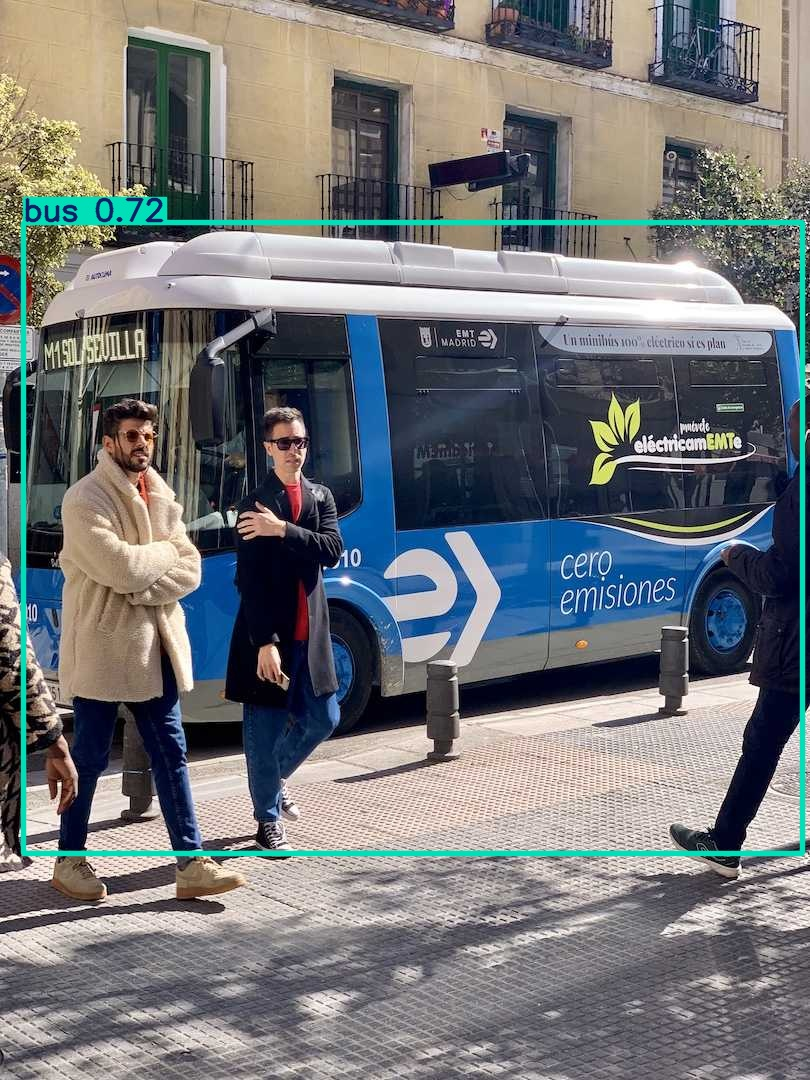

In [ ]:
# Already in Colab — just run this
from ultralytics import YOLO

model = YOLO("runs/detect/hexapod_obstacle/weights/best.pt")

# Test on a sample image
!wget -q https://ultralytics.com/images/bus.jpg
results = model("bus.jpg", conf=0.5)
results[0].save("output.jpg")

from google.colab.patches import cv2_imshow
import cv2
cv2_imshow(cv2.imread("output.jpg"))